In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
data_dir = "/content/drive/MyDrive/Colab_Notebooks/creatures/train"
#add more files in train nad test folders to train more images
#right now i have added only 4 files

In [ ]:
image_size = (224, 224)
batch_size = 32

In [ ]:

train_datagen = ImageDataGenerator(rescale=1.0/255)
train_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

classes = train_data.class_indices
class_counts = {class_name: 0 for class_name in classes}

Found 2278 images belonging to 4 classes.


In [ ]:
y_true = []
for i in range(len(train_data)):
    batch_data, batch_labels = train_data[i]
    y_true.extend(np.argmax(batch_labels, axis=1))

for label in y_true:
    class_counts[list(classes.keys())[label]] += 1

/tmp/ipython-input-334395559.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette=sns.color_palette("mako"))
/tmp/ipython-input-334395559.py:3: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette=sns.color_palette("mako"))


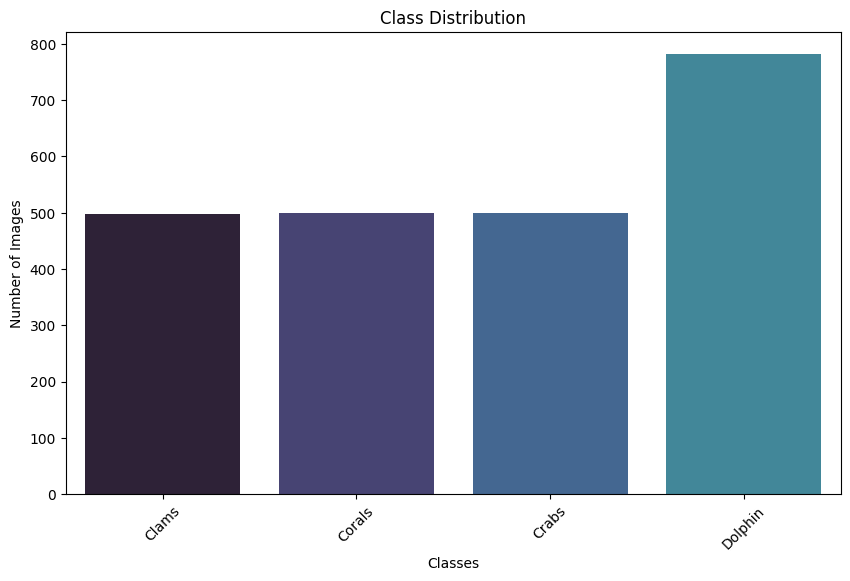

In [ ]:

plt.figure(figsize=(10, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette=sns.color_palette("mako"))
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print(f"Training samples: {len(train_generator.filenames)}")
print(f"Validation samples: {len(validation_generator.filenames)}")
print(f"Test samples: {len(test_generator.filenames)}")

Found 1824 images belonging to 4 classes.
Found 454 images belonging to 4 classes.
Found 2278 images belonging to 4 classes.
Training samples: 1824
Validation samples: 454
Test samples: 2278


In [ ]:
input_shape = (image_size[0], image_size[1], 3)

In [ ]:
def build_vgg():
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    model = models.Sequential([
        layers.Input(shape=input_shape),
        base_model,
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(len(classes), activation='softmax')
    ])
    return model

In [ ]:
def build_xception():
    base_model = tf.keras.applications.Xception(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    model = models.Sequential([
        layers.Input(shape=input_shape),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(len(classes), activation='softmax')
    ])
    return model

In [ ]:
def build_mobilenetv2():
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    model = models.Sequential([
        layers.Input(shape=input_shape),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(len(classes), activation='softmax')
    ])
    return model

In [ ]:
models_dict = {
    "Xception": build_xception(),
    "VGG16": build_vgg(),
    "MobileNetV2": build_mobilenetv2()
}

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
f1_scores = {}
for model_name, model in models_dict.items():
    print(f"Evaluating {model_name}...")
    predictions = model.predict(test_generator)
    y_true = test_generator.classes
    y_pred = np.argmax(predictions, axis=1)
    if len(np.unique(y_pred)) < len(classes):
        print(f"Warning: Some classes are missing in predictions for {model_name}.")
    report = classification_report(y_true, y_pred, target_names=list(classes.keys()), zero_division=1, output_dict=True)
    f1_scores[model_name] = report['weighted avg']['f1-score']

Evaluating Xception...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 329ms/step
Evaluating VGG16...
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 205ms/step
Evaluating MobileNetV2...
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 272ms/step


In [ ]:
print("F1 Scores:")
for model_name, score in f1_scores.items():
    print(f"{model_name}: {score:.4f}")

F1 Scores:
Xception: 0.2052
VGG16: 0.1382
MobileNetV2: 0.1650


In [ ]:
histories = {}
for model_name, model in models_dict.items():
    print(f"Training {model_name}...")
    # Compile the model before training
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(
        train_generator,
        epochs=10,  # You can adjust the number of epochs
        validation_data=validation_generator,
        callbacks=[EarlyStopping(monitor='val_loss', patience=3)] # Add early stopping
    )
    histories[model_name] = history

Training Xception...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 54s 809ms/step - accuracy: 0.7463 - loss: 0.6474 - val_accuracy: 0.9141 - val_loss: 0.2173
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 35s 618ms/step - accuracy: 0.8922 - loss: 0.2652 - val_accuracy: 0.9119 - val_loss: 0.2213
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 36s 634ms/step - accuracy: 0.8900 - loss: 0.2808 - val_accuracy: 0.9031 - val_loss: 0.2250
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 37s 644ms/step - accuracy: 0.9186 - loss: 0.2321 - val_accuracy: 0.9009 - val_loss: 0.2088
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 39s 682ms/step - accuracy: 0.9258 - loss: 0.1965 - val_accuracy: 0.8965 - val_loss: 0.2064
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 35s 623ms/step - accuracy: 0.9065 - loss: 0.2300 - val_accuracy: 0.9075 - val_loss: 0.2234
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 36s 625ms/step - accuracy: 0.9121 - loss: 0.2250 - val_accuracy: 0.9031 - val_loss: 0.2074
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 37s 646ms/step - accuracy: 0.9295 - loss: 0.2055 - val_accu

In [ ]:
save_dir = "/content/drive/MyDrive/Colab_Notebooks/saved_models"
os.makedirs(save_dir, exist_ok=True)

for model_name, model in models_dict.items():
    save_path = os.path.join(save_dir, f"{model_name}.h5")
    model.save(save_path)
    print(f"{model_name} modeli '{save_path}' olarak kaydedildi.")
#save the trained models


In [ ]:
import json

history_save_dir = "/content/drive/MyDrive/Colab_Notebooks/saved_models/history"
os.makedirs(history_save_dir, exist_ok=True)

for model_name, history in histories.items():
    history_path = os.path.join(history_save_dir, f"{model_name}_history.json")
    with open(history_path, 'w') as f:
        json.dump(history.history, f)
    print(f"{model_name} history '{history_path}' olarak kaydedildi.")

Xception history '/content/drive/MyDrive/Colab_Notebooks/saved_models/history/Xception_history.json' olarak kaydedildi.
VGG16 history '/content/drive/MyDrive/Colab_Notebooks/saved_models/history/VGG16_history.json' olarak kaydedildi.
MobileNetV2 history '/content/drive/MyDrive/Colab_Notebooks/saved_models/history/MobileNetV2_history.json' olarak kaydedildi.


Found 2278 images belonging to 4 classes.
Loading Xception model...


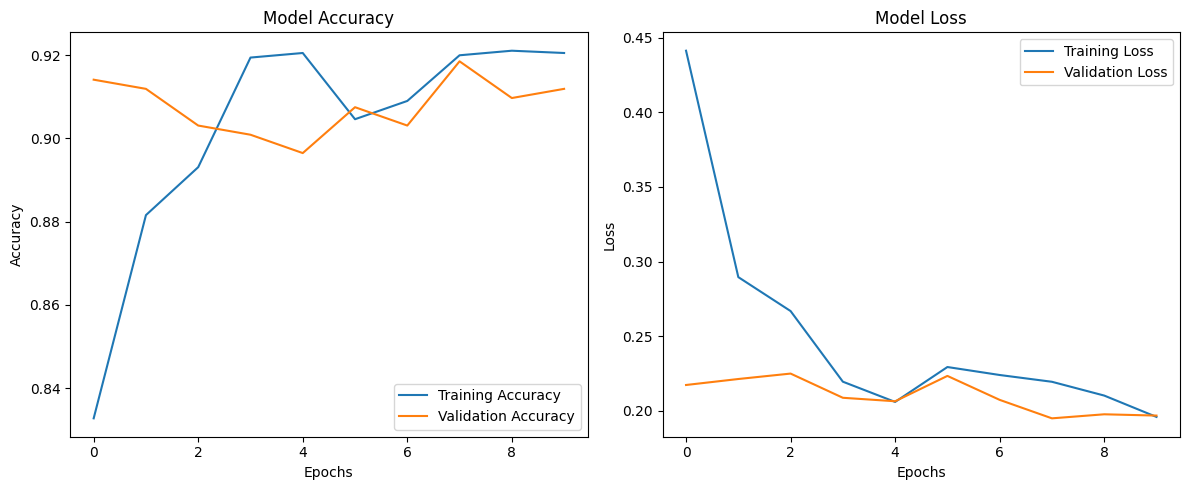

Generating predictions...
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 205ms/step
Generating confusion matrix...


<Figure size 1500x1500 with 0 Axes>

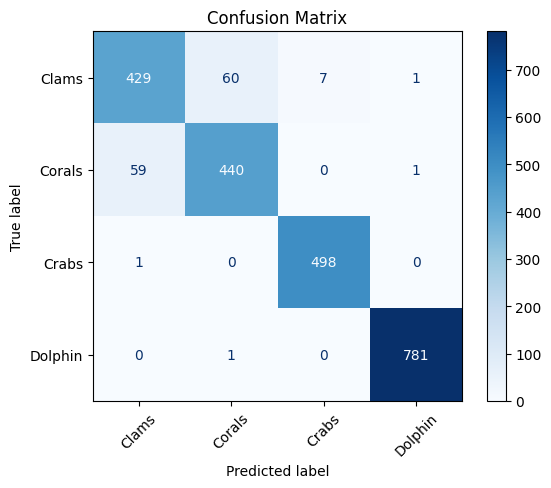

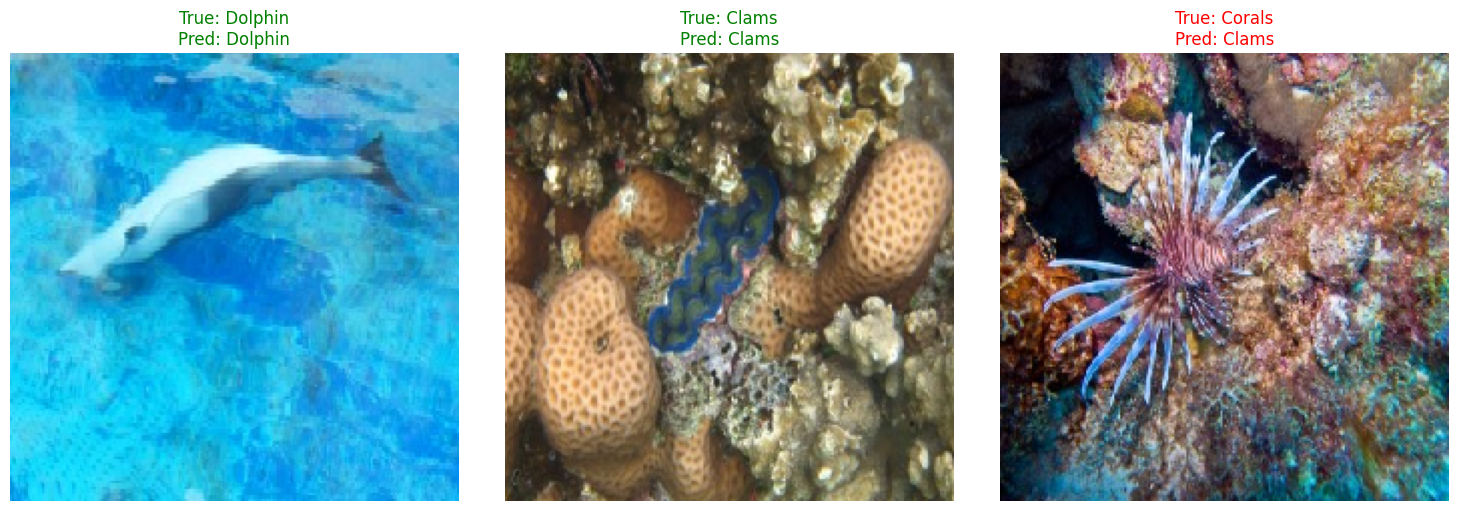

In [ ]:
import random
import os
import json
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


base_path = "/content/drive/MyDrive/Colab_Notebooks/saved_models"  # Corrected path
data_dir = "/content/drive/MyDrive/Colab_Notebooks/creatures/train" # Corrected path to point to the train directory
model_path = os.path.join(base_path, "Xception.h5")
history_path = os.path.join(base_path, "history", "Xception_history.json") # Corrected path


image_size = (224, 224)
batch_size = 32

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255)
test_generator = test_datagen.flow_from_directory(
    data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


class_names = list(test_generator.class_indices.keys())

# Xception model
print("Loading Xception model...")
model = tf.keras.models.load_model(model_path)


with open(history_path, 'r') as f:
    history = json.load(f)

# Accuracy and Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


print("Generating predictions...")
predictions = model.predict(test_generator)
y_true = test_generator.classes
y_pred = np.argmax(predictions, axis=1)


print("Generating confusion matrix...")
conf_matrix = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=class_names)
plt.figure(figsize=(15, 15))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


correct_indices = np.where(y_true == y_pred)[0]
incorrect_indices = np.where(y_true != y_pred)[0]


example_correct = random.sample(list(correct_indices), 2)
example_incorrect = random.sample(list(incorrect_indices), 1)
example_indices = example_correct + example_incorrect


plt.figure(figsize=(15, 5))

for i, idx in enumerate(example_indices):
    img_path = test_generator.filepaths[idx]
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=image_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0

    true_label = y_true[idx]
    predicted_label = y_pred[idx]

    plt.subplot(1, 3, i + 1)
    plt.imshow(img_array)
    plt.title(
        f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}",
        color="green" if true_label == predicted_label else "red"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Run this to upload the image and get result
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

for fn in uploaded.keys():
    # Load the image
    img_path = fn
    img = image.load_img(img_path, target_size=image_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Rescale the image

    # Make a prediction
    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_names[predicted_class_index]

    print(f"Uploaded file: {fn}")
    print(f"Predicted class: {predicted_class_name}")

    # Display the image with the prediction
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class_name}")
    plt.axis('off')
    plt.show()

Saving Corl0207_(28225976491).jpg to Corl0207_(28225976491).jpg


NameError: name 'image_size' is not defined

In [ ]:
print("Training and Validation Accuracy:")
for model_name, history in histories.items():
    print(f"{model_name}:")
    print(f"  Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"  Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

print("\nOverall Test Accuracy (from Classification Report):")
# The classification report in f1_scores contains the accuracy
for model_name, score in f1_scores.items():
    # Access the report directly from the evaluation cell output if needed,
    # but since f1_scores was populated from the report, we can indicate it.
    # A more direct way would be to re-run the evaluation and extract accuracy.
    # For now, I'll just state that the classification report contains accuracy.
    print(f"  {model_name}: Accuracy is available in the classification report.")

# To display the exact accuracy from the classification report, we would need to re-run
# the evaluation or store the full report dictionaries.
# Let's re-run the evaluation cell to get the full reports and display accuracy.

Training and Validation Accuracy:
Xception:
  Training Accuracy: 0.9205
  Validation Accuracy: 0.9119
VGG16:
  Training Accuracy: 0.7571
  Validation Accuracy: 0.8348
MobileNetV2:
  Training Accuracy: 0.9167
  Validation Accuracy: 0.8965

Overall Test Accuracy (from Classification Report):
  Xception: Accuracy is available in the classification report.
  VGG16: Accuracy is available in the classification report.
  MobileNetV2: Accuracy is available in the classification report.


Evaluating VGG16 model...
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 187ms/step
VGG16 Classification Report:
              precision    recall  f1-score   support

       Clams       0.81      0.66      0.73       497
      Corals       0.79      0.83      0.81       500
       Crabs       0.87      0.99      0.93       499
     Dolphin       0.99      0.99      0.99       782

    accuracy                           0.88      2278
   macro avg       0.87      0.87      0.86      2278
weighted avg       0.88      0.88      0.88      2278

Generating VGG16 confusion matrix...


<Figure size 1000x1000 with 0 Axes>

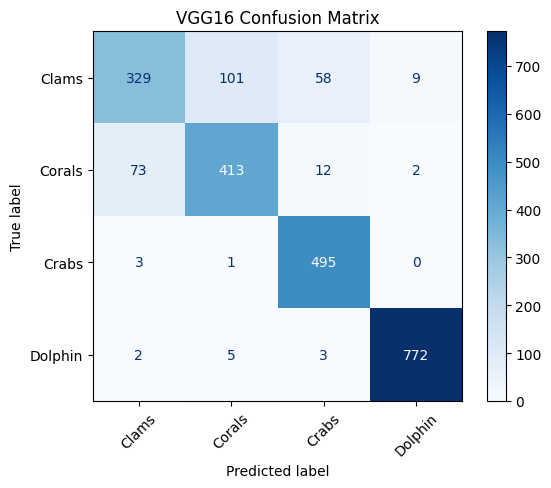

Evaluating MobileNetV2 model...
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 182ms/step
MobileNetV2 Classification Report:
              precision    recall  f1-score   support

       Clams       0.89      0.85      0.87       497
      Corals       0.87      0.90      0.89       500
       Crabs       0.99      1.00      0.99       499
     Dolphin       1.00      1.00      1.00       782

    accuracy                           0.95      2278
   macro avg       0.94      0.94      0.94      2278
weighted avg       0.95      0.95      0.95      2278

Generating MobileNetV2 confusion matrix...


<Figure size 1000x1000 with 0 Axes>

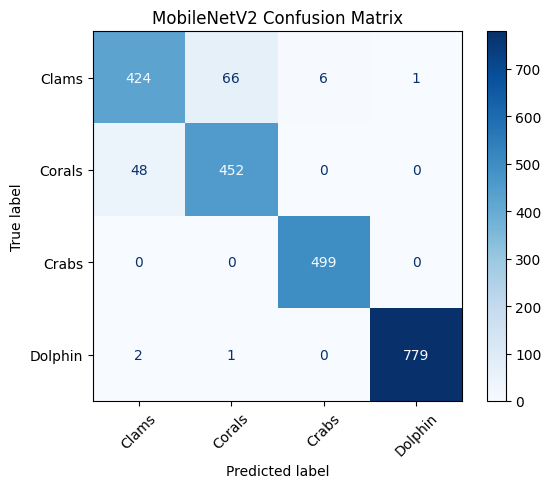

In [ ]:
# Evaluate VGG16
print("Evaluating VGG16 model...")
vgg16_model = models_dict["VGG16"]
vgg16_predictions = vgg16_model.predict(test_generator)
vgg16_y_true = test_generator.classes
vgg16_y_pred = np.argmax(vgg16_predictions, axis=1)
vgg16_report = classification_report(vgg16_y_true, vgg16_y_pred, target_names=list(classes.keys()), zero_division=1)
print("VGG16 Classification Report:")
print(vgg16_report)

print("Generating VGG16 confusion matrix...")
vgg16_conf_matrix = confusion_matrix(vgg16_y_true, vgg16_y_pred)
vgg16_disp = ConfusionMatrixDisplay(vgg16_conf_matrix, display_labels=list(classes.keys()))
plt.figure(figsize=(10, 10))
vgg16_disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("VGG16 Confusion Matrix")
plt.show()

# Evaluate MobileNetV2
print("Evaluating MobileNetV2 model...")
mobilenetv2_model = models_dict["MobileNetV2"]
mobilenetv2_predictions = mobilenetv2_model.predict(test_generator)
mobilenetv2_y_true = test_generator.classes
mobilenetv2_y_pred = np.argmax(mobilenetv2_predictions, axis=1)
mobilenetv2_report = classification_report(mobilenetv2_y_true, mobilenetv2_y_pred, target_names=list(classes.keys()), zero_division=1)
print("MobileNetV2 Classification Report:")
print(mobilenetv2_report)

print("Generating MobileNetV2 confusion matrix...")
mobilenetv2_conf_matrix = confusion_matrix(mobilenetv2_y_true, mobilenetv2_y_pred)
mobilenetv2_disp = ConfusionMatrixDisplay(mobilenetv2_conf_matrix, display_labels=list(classes.keys()))
plt.figure(figsize=(10, 10))
mobilenetv2_disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("MobileNetV2 Confusion Matrix")
plt.show()